# Project 4: Data Visualization and Storytelling

**Executive question:** What should leadership act on after reviewing the e-commerce order data?

This notebook uses action-oriented titles, direct labels, restrained color, honest axes, and comparable periods. `TotalPrice` is treated as gross order value because the dataset contains orders that are cancelled, returned, pending, shipped, and delivered.

In [1]:
from pathlib import Path
from IPython.display import Image, display
from data_visualization import build_tables, load_and_validate, run

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'data_visualization.py').exists():
    PROJECT_DIR = PROJECT_DIR / 'Project_04'

INPUT = PROJECT_DIR / 'Dataset for Data Analytics.xlsx'
OUTPUT = PROJECT_DIR / 'outputs'
generated = run(INPUT, OUTPUT)
generated

[WindowsPath('d:/coding/DecodeLabs-Internship/Project_04/outputs/analysis_ready_orders.csv'),
 WindowsPath('d:/coding/DecodeLabs-Internship/Project_04/outputs/key_metrics.csv'),
 WindowsPath('d:/coding/DecodeLabs-Internship/Project_04/outputs/00_executive_dashboard.png'),
 WindowsPath('d:/coding/DecodeLabs-Internship/Project_04/outputs/01_h1_gross_order_value.png'),
 WindowsPath('d:/coding/DecodeLabs-Internship/Project_04/outputs/02_product_performance.png'),
 WindowsPath('d:/coding/DecodeLabs-Internship/Project_04/outputs/03_order_status_distribution.png'),
 WindowsPath('d:/coding/DecodeLabs-Internship/Project_04/outputs/04_referral_source_performance.png'),
 WindowsPath('d:/coding/DecodeLabs-Internship/Project_04/outputs/05_coupon_average_order_value.png'),
 WindowsPath('d:/coding/DecodeLabs-Internship/Project_04/outputs/executive_report.html')]

## Data quality and scope

- 1,200 unique orders
- Date range: January 2023 to June 2025
- Coupon absence is labeled `NO_COUPON`
- `TotalPrice = Quantity x UnitPrice` is validated for every row
- 2025 is a partial year, so the trend comparison uses January-June for every year

In [2]:
df = load_and_validate(INPUT)
tables = build_tables(df)
df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].describe().round(2)

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.00,1200.00,1200.00,1200.00
mean,2.95,356.41,5.48,1053.97
std,1.41,197.18,2.28,819.86
min,1.00,11.39,1.00,11.39
25%,2.00,186.06,4.00,410.52
50%,3.00,364.21,5.00,823.62
75%,4.00,521.57,7.00,1578.48
max,5.00,699.93,10.00,3456.40


## Executive dashboard

The core story is visible in one frame: comparable H1 value is weakening, while cancellation and return exposure remains the largest operational concern.

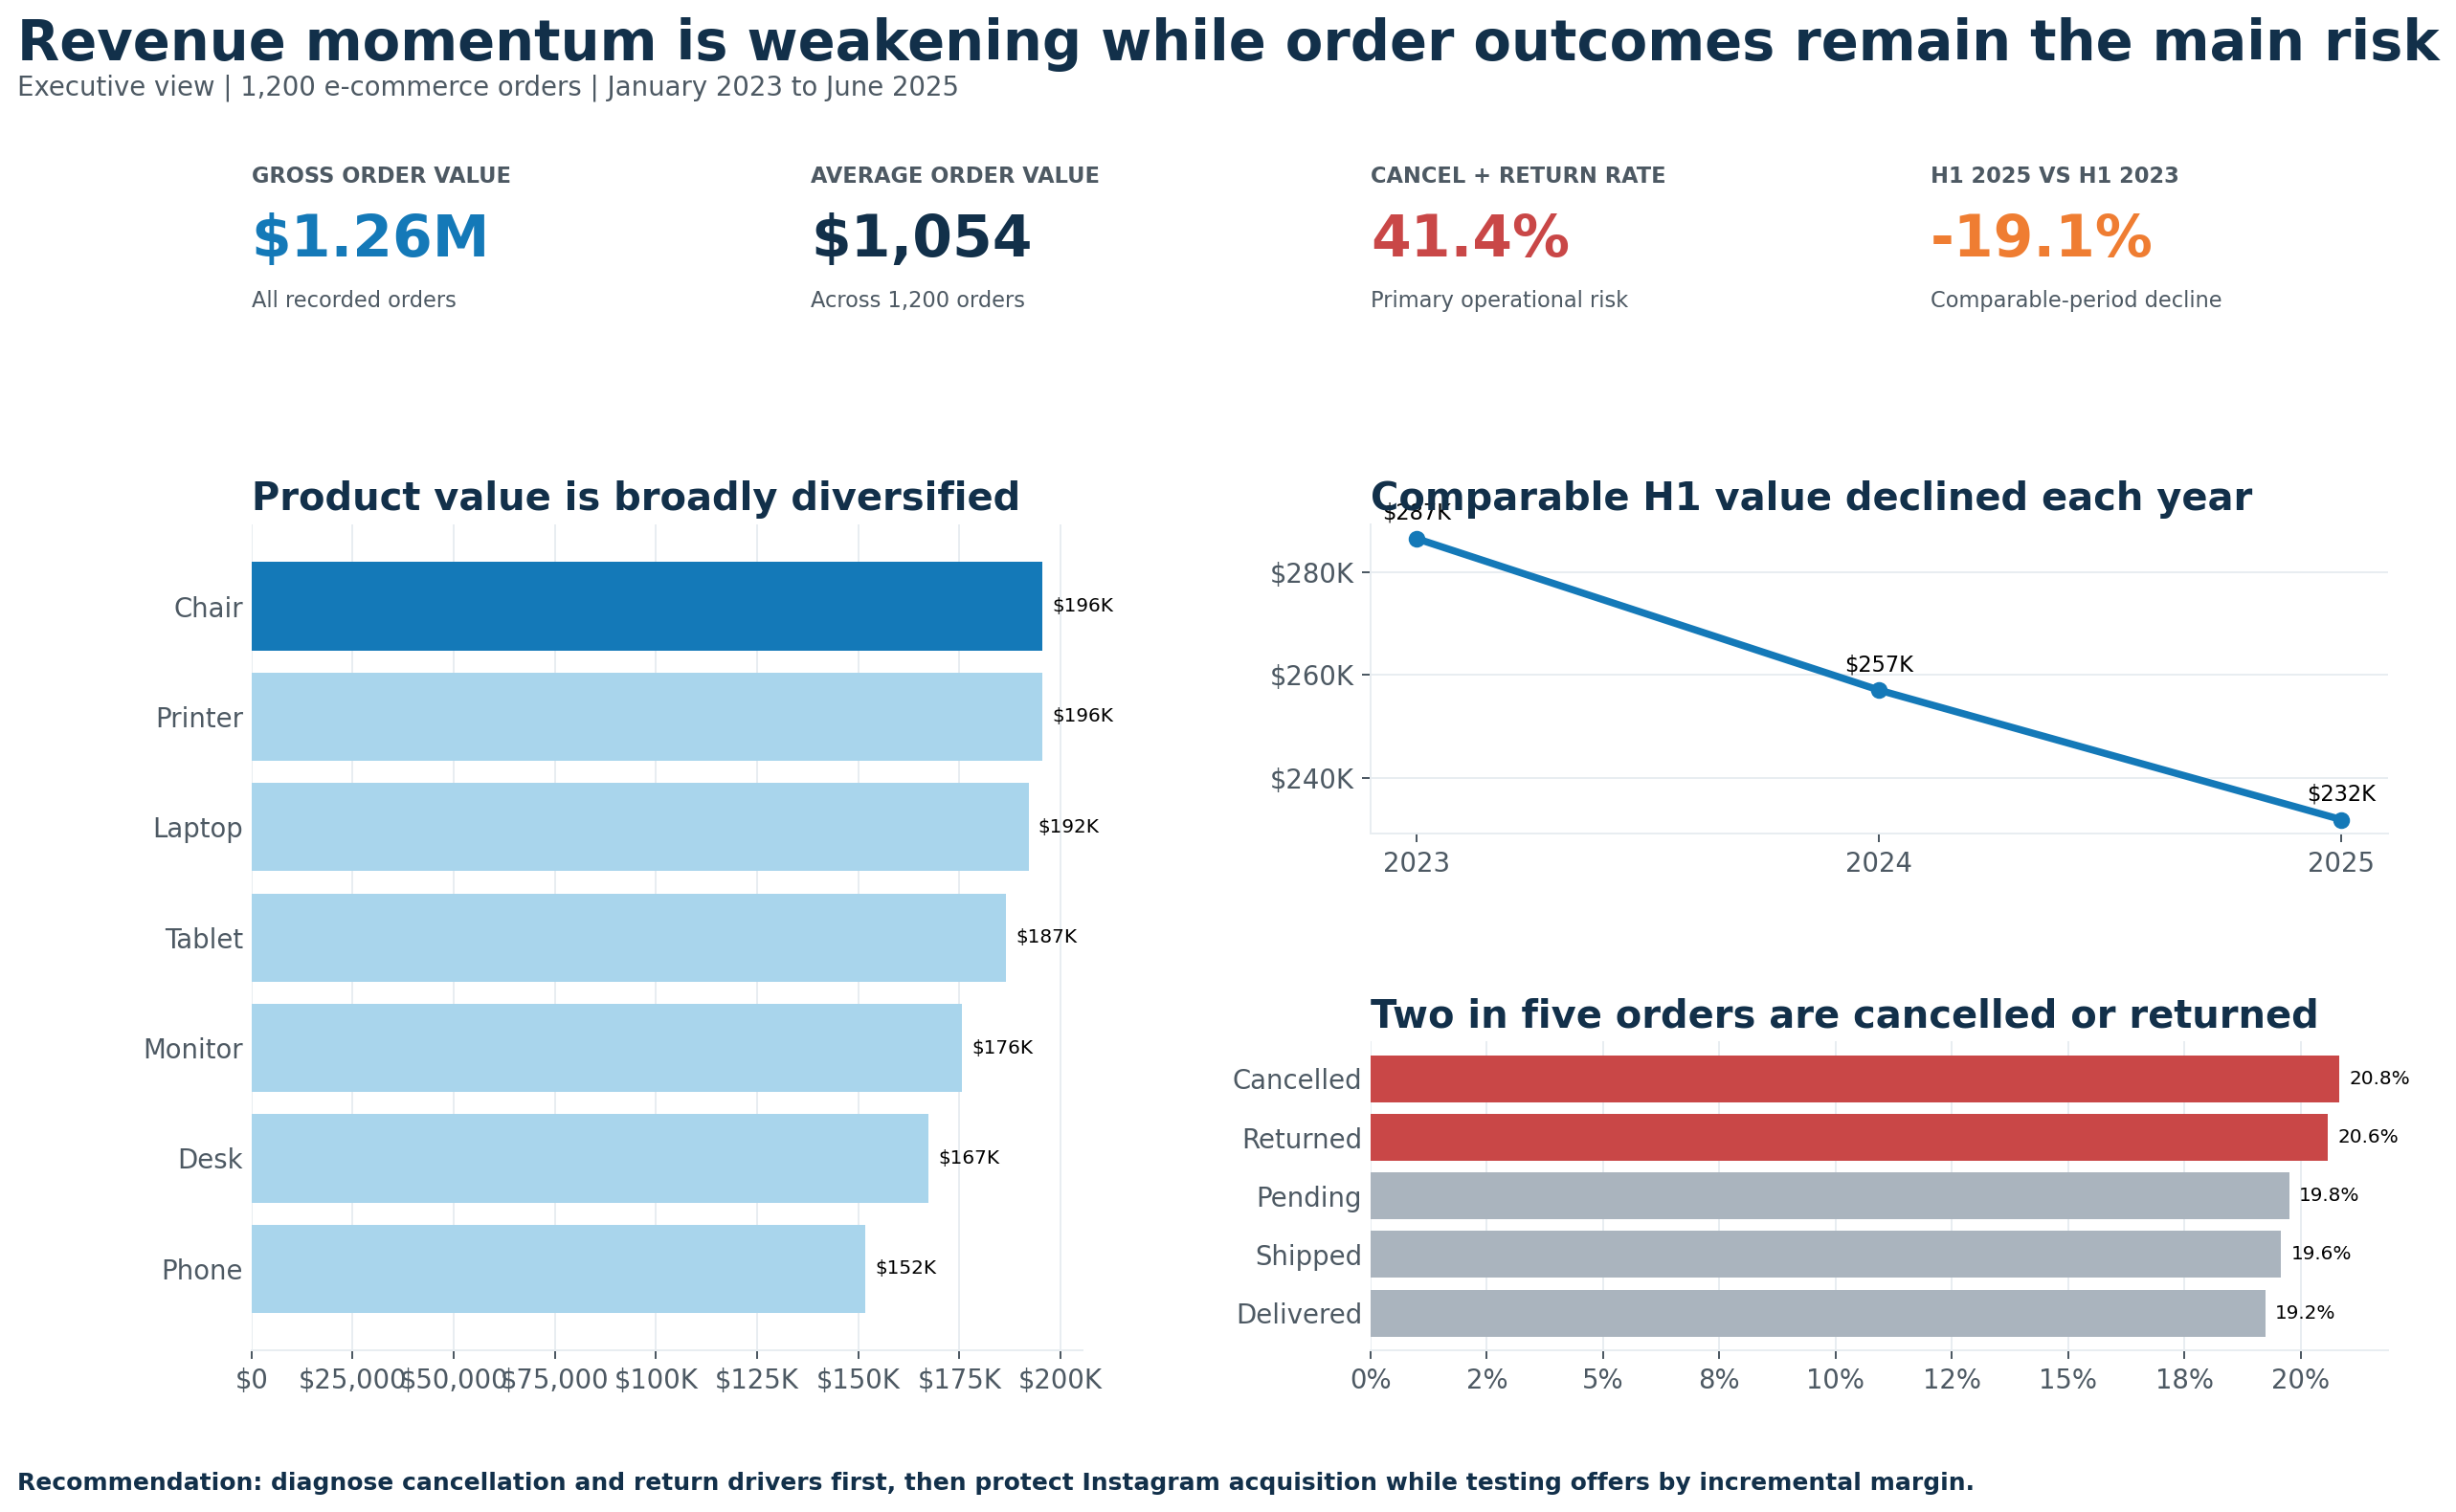

In [3]:
display(Image(filename=str(OUTPUT / '00_executive_dashboard.png')))

## Supporting evidence

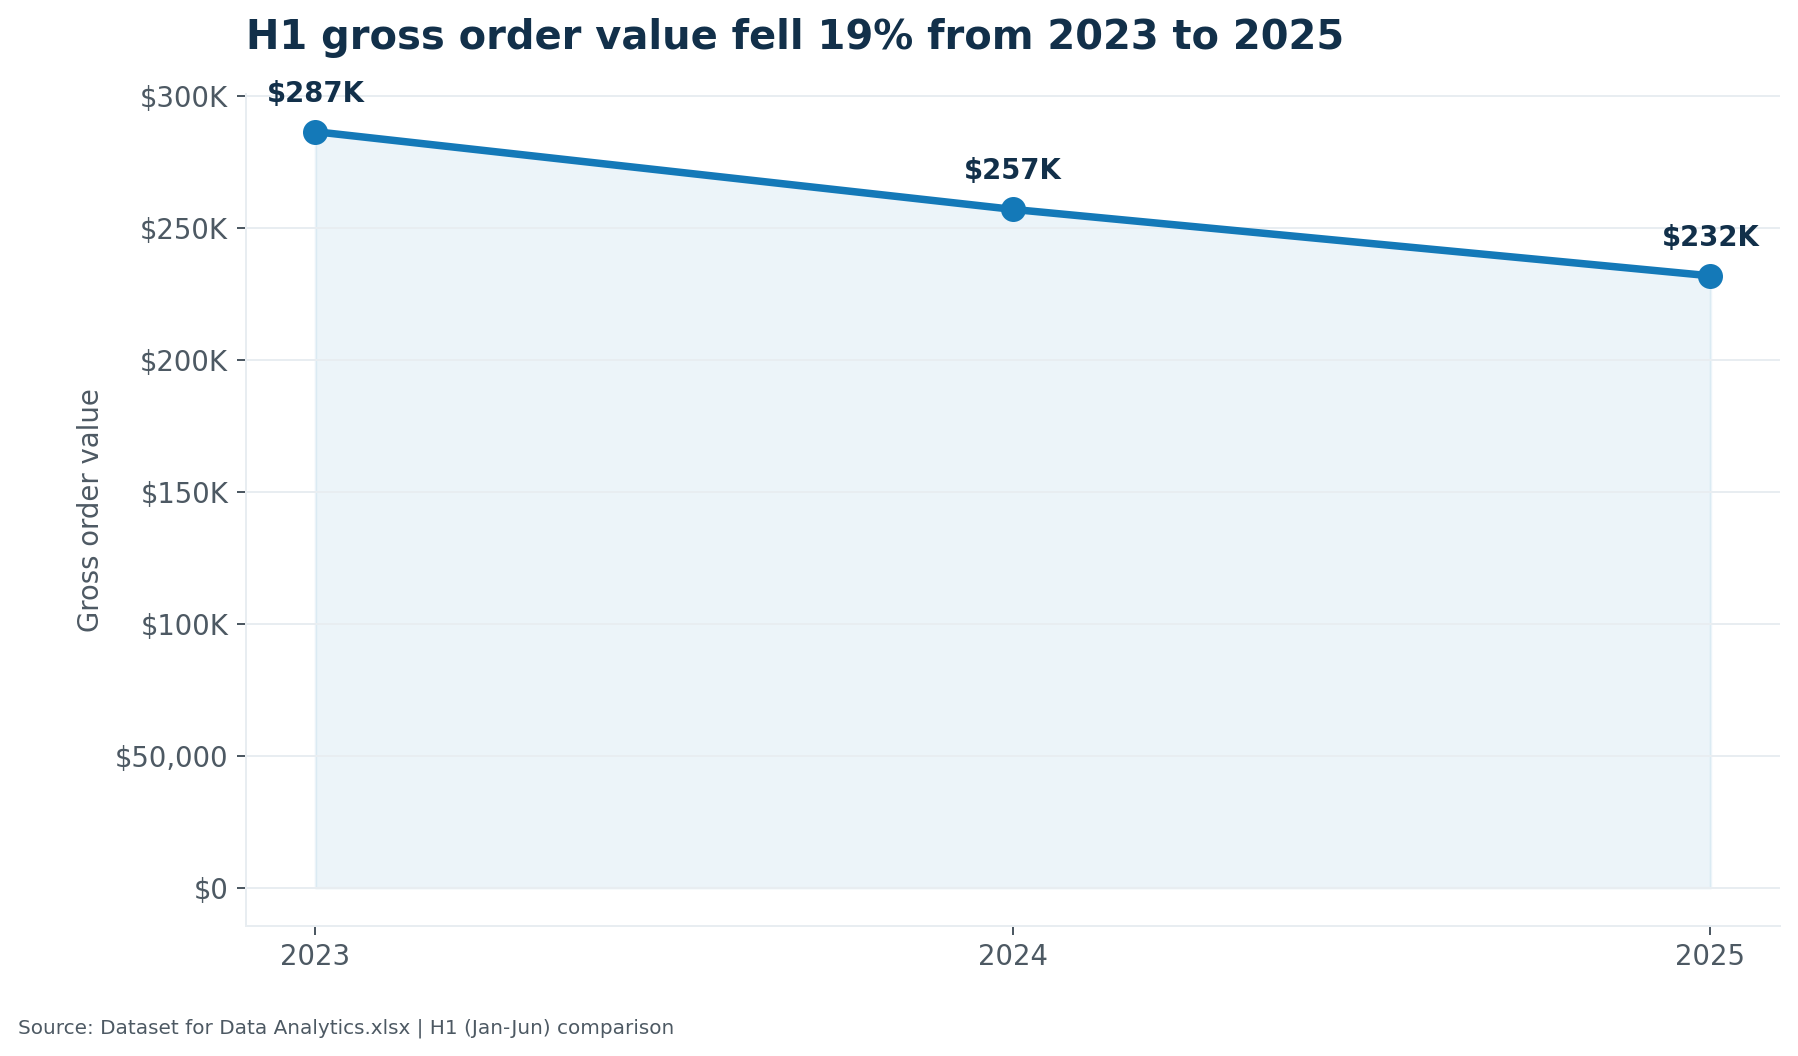

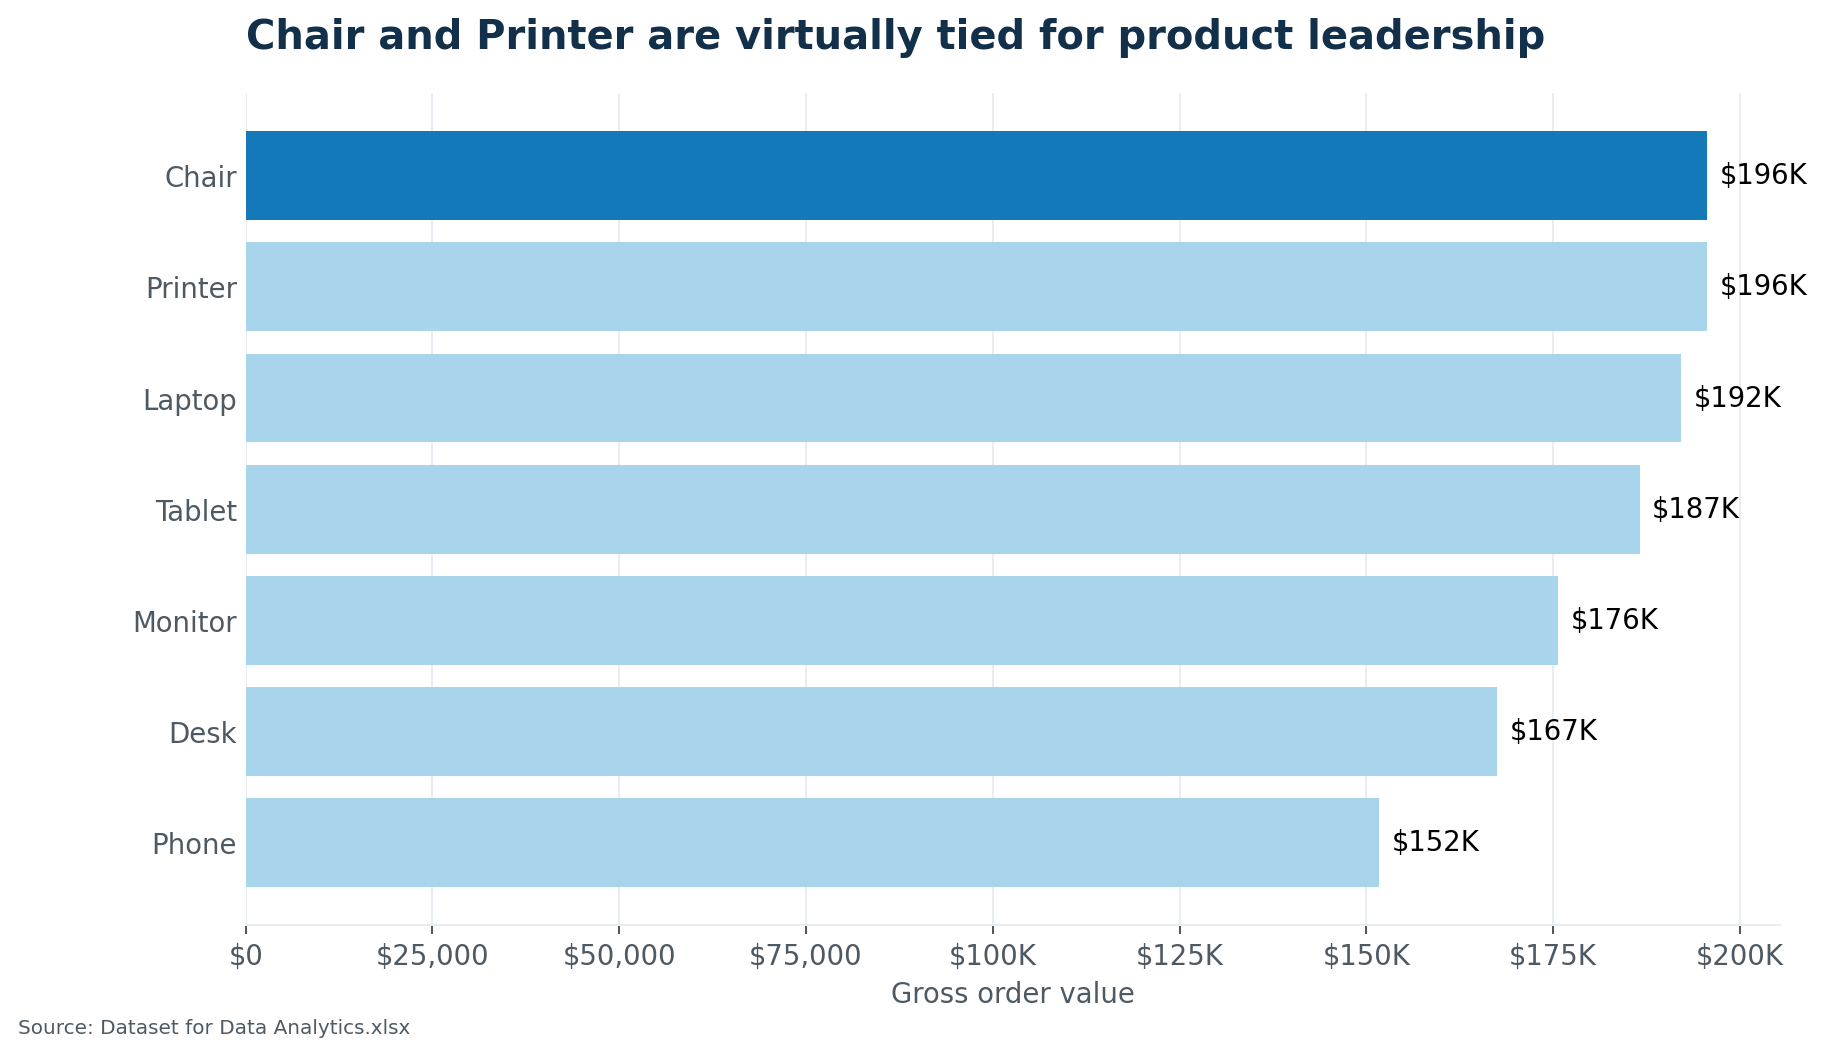

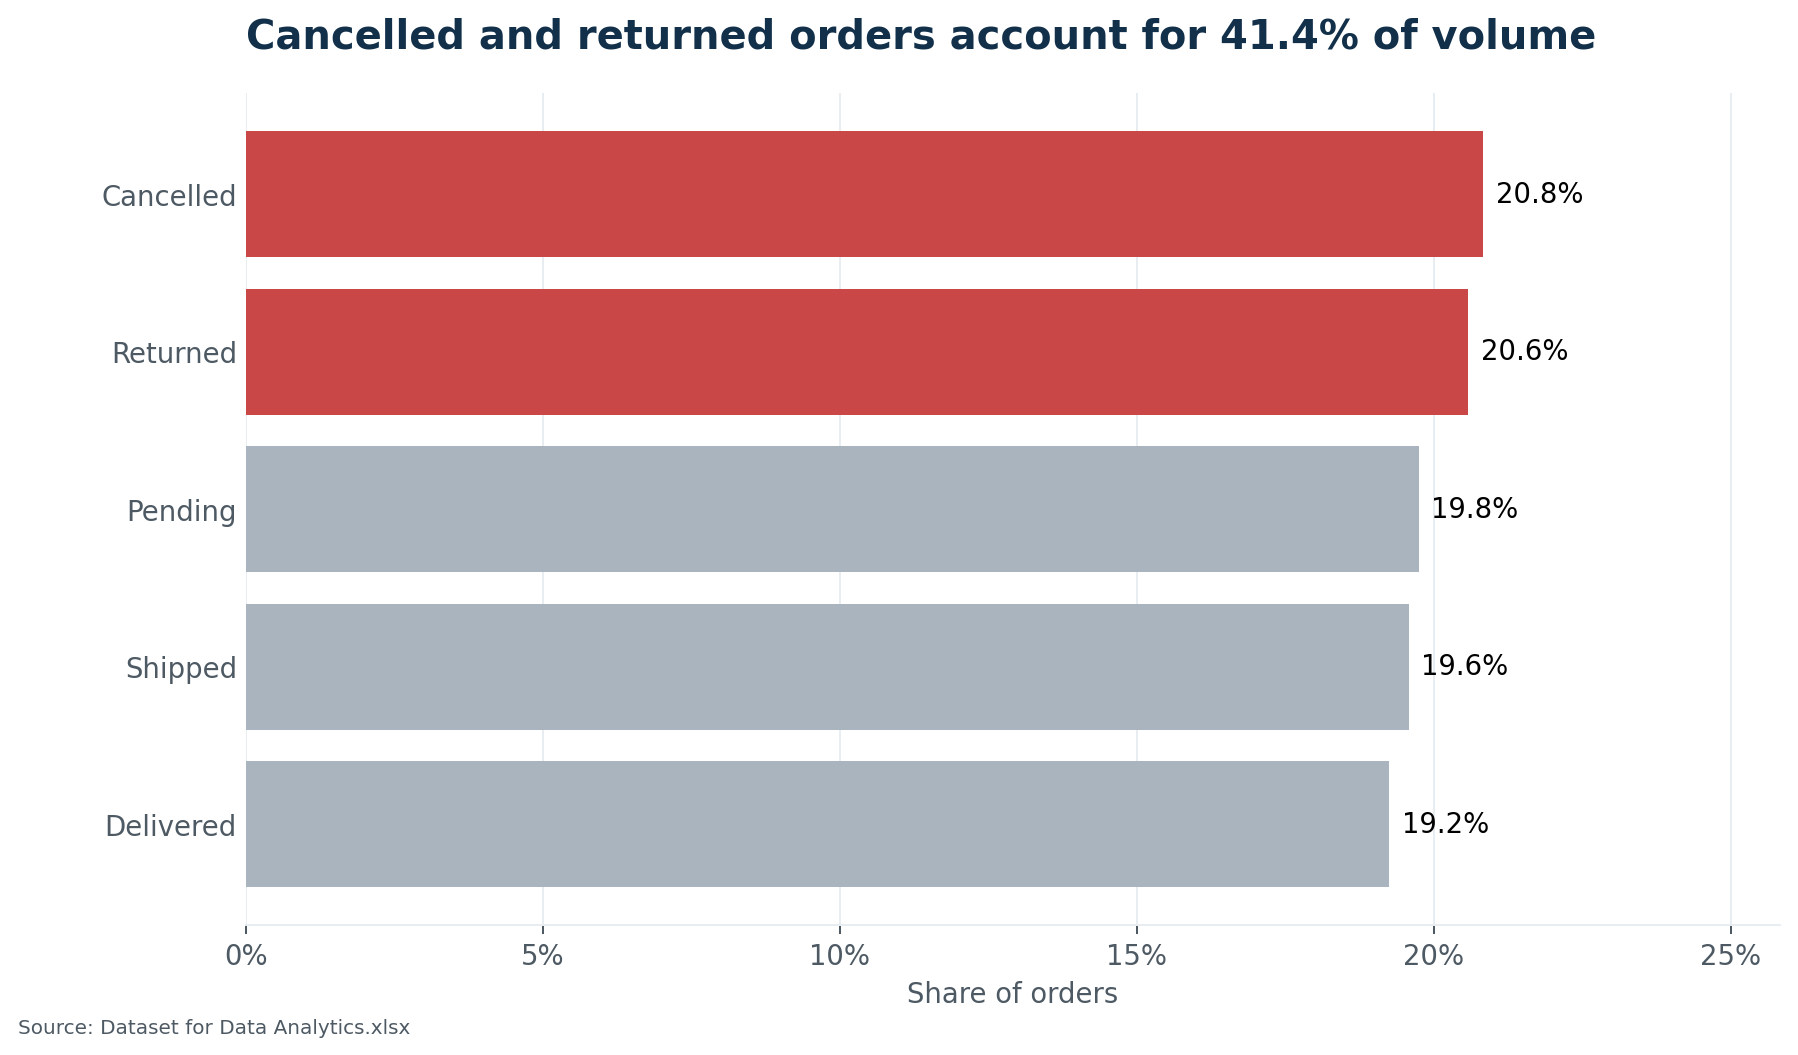

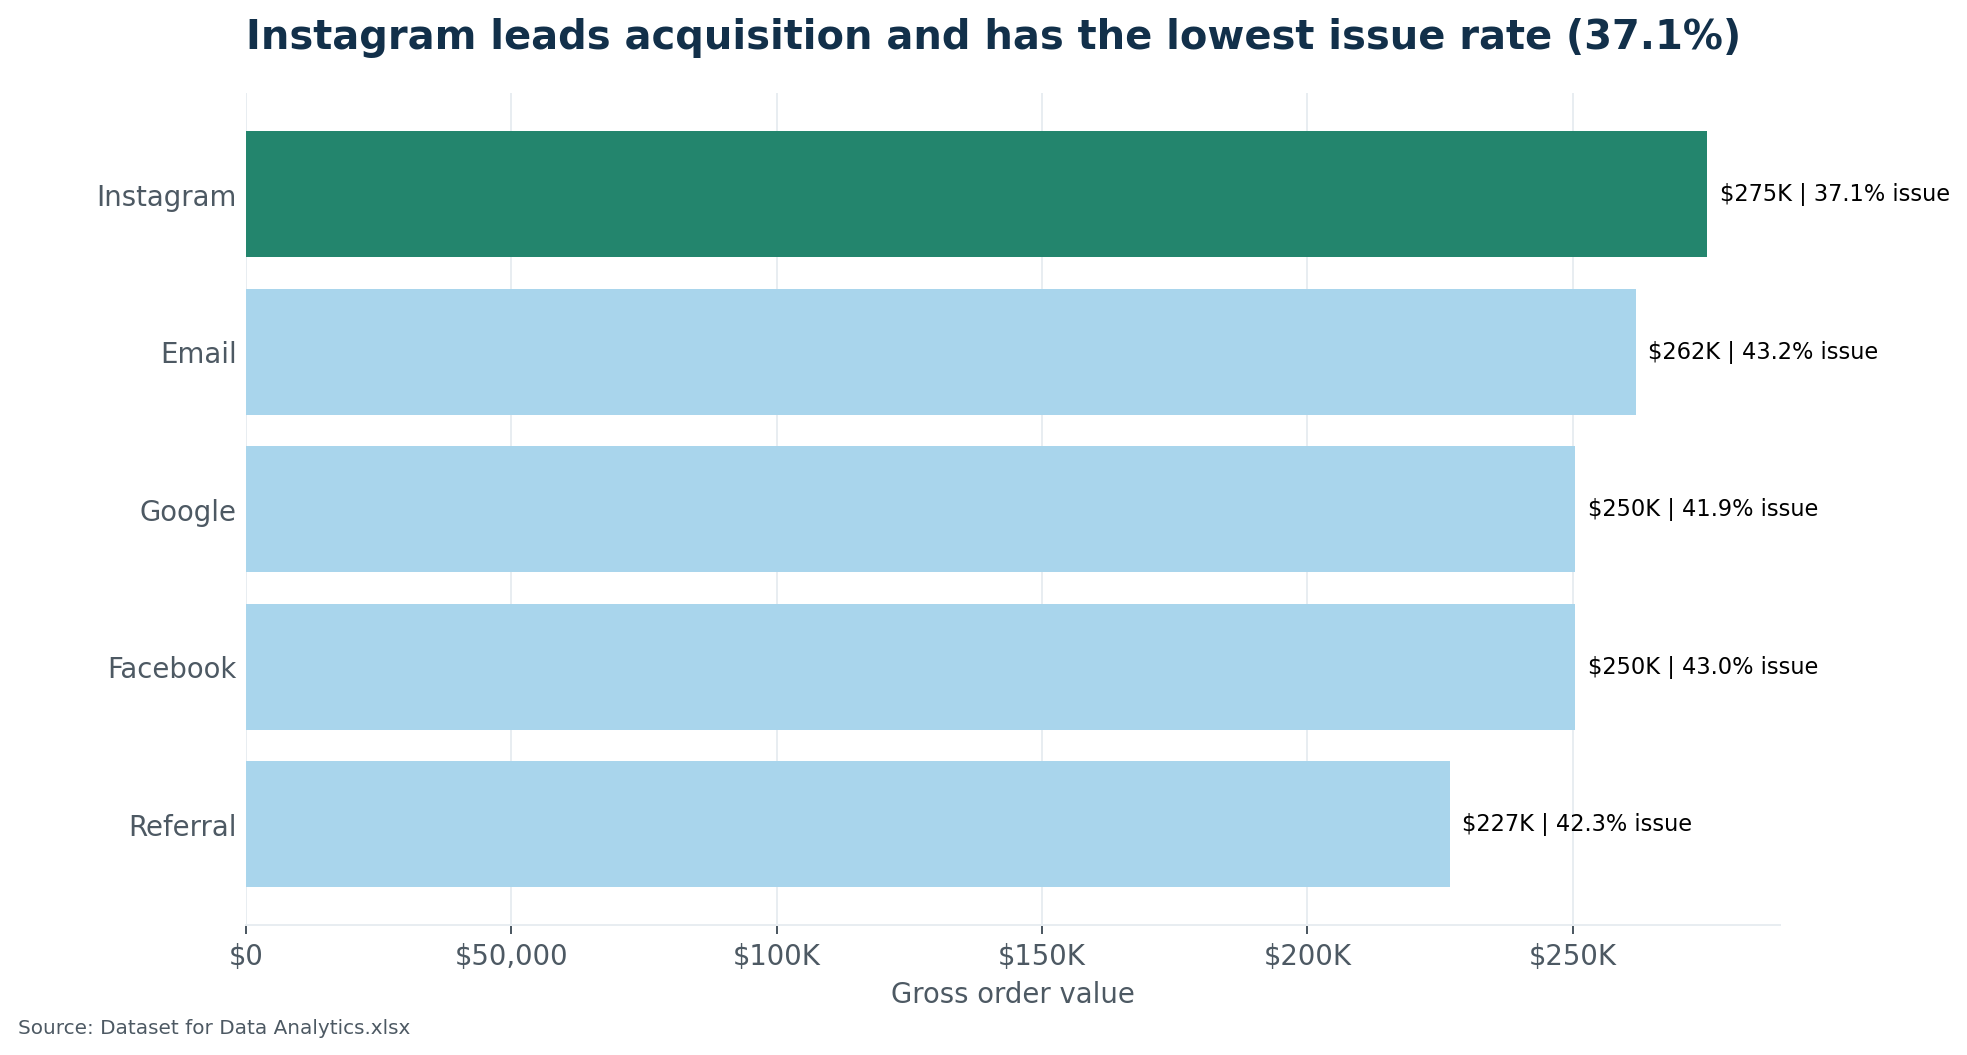

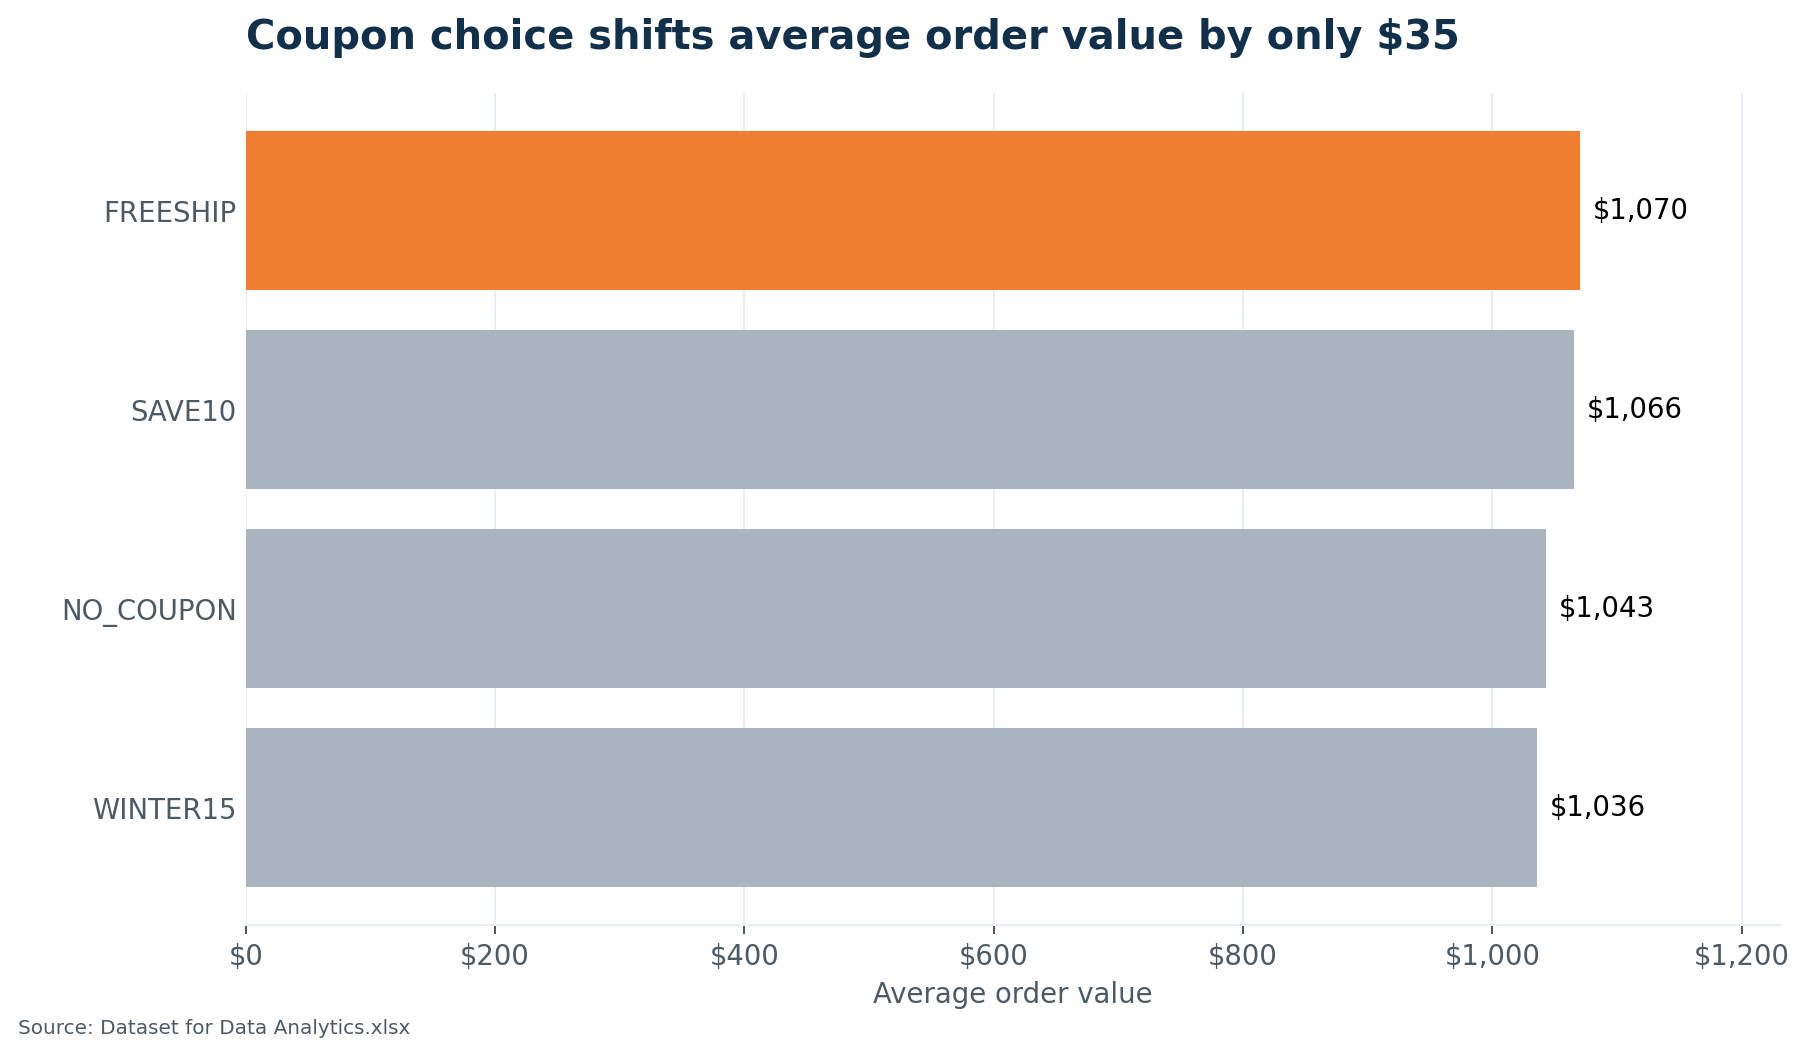

In [4]:
for chart in [
    '01_h1_gross_order_value.png',
    '02_product_performance.png',
    '03_order_status_distribution.png',
    '04_referral_source_performance.png',
    '05_coupon_average_order_value.png',
]:
    display(Image(filename=str(OUTPUT / chart)))

## Findings

1. H1 gross order value declined 19.1% from 2023 to 2025.
2. Cancelled and returned orders account for 41.42% of volume.
3. Chair and Printer are effectively tied for product leadership, so value is not dependent on one item.
4. Instagram leads gross order value and has the lowest issue rate among referral sources.
5. Coupon-level AOV differs by only $34.50, so offers alone are unlikely to reverse the broader trend.

## Recommended action

1. Investigate cancellation and return causes by product and referral source before increasing demand spend.
2. Protect and selectively scale Instagram acquisition while tracking completed-order quality.
3. Evaluate coupon tests using incremental profit and completed-order conversion rather than gross order value alone.
4. Continue monthly and comparable H1 reporting to avoid partial-year distortion.